# Task 3 — Stock Price Data Visualization

This project analyzes the historical stock price of Apple Inc. (AAPL) using time-series visualizations.

The analysis includes:
- Closing price trend
- 20-day and 50-day moving averages
- Daily returns distribution
- Brief interpretation of the stock's return and volatility

**Data Source:** Yahoo Finance via yfinance  
**Ticker:** AAPL

In [5]:
# Import the libraries needed for data collection, analysis, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Set the stock ticker and analysis date range
TICKER = "AAPL"
START_DATE = "2024-01-01"
END_DATE = "2025-01-01"

# Display the selected settings
print(f"Ticker: {TICKER}")
print(f"Start Date: {START_DATE}")
print(f"End Date: {END_DATE}")

Ticker: AAPL
Start Date: 2024-01-01
End Date: 2025-01-01


In [6]:
# Download AAPL historical stock data from Yahoo Finance
df = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    progress=False,
    multi_level_index=False
)

# Check if data was successfully downloaded
if df.empty:
    raise ValueError("No stock data was returned. Check the ticker and date range.")

# Display the first five rows of the downloaded data
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2024-01-02,183.404037,185.639999,188.440002,183.889999,187.149994,82488700
2024-01-03,182.030746,184.250000,185.880005,183.429993,184.220001,58414500
2024-01-04,179.718933,181.910004,183.089996,180.880005,182.149994,71983600
2024-01-05,178.997711,181.179993,182.759995,180.169998,181.990005,62379700
2024-01-08,183.324997,185.559998,185.600006,181.500000,182.089996,59144500


In [7]:
# Keep only the columns needed for the stock price analysis
df = df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].copy()

# Calculate the 20-day moving average of the closing price
df["MA20"] = df["Close"].rolling(window=20).mean()

# Calculate the 50-day moving average of the closing price
df["MA50"] = df["Close"].rolling(window=50).mean()

# Calculate the daily percentage return based on the closing price
df["Daily_Return"] = df["Close"].pct_change()

# Display the first few rows of the prepared dataset
df.head()

,Open,High,Low,Close,Adj Close,Volume,MA20,MA50,Daily_Return
Date,,,,,,,,,
2024-01-02,187.149994,188.440002,183.889999,185.639999,183.404037,82488700,NaN,NaN,NaN
2024-01-03,184.220001,185.880005,183.429993,184.250000,182.030746,58414500,NaN,NaN,-0.007488
2024-01-04,182.149994,183.089996,180.880005,181.910004,179.718933,71983600,NaN,NaN,-0.012700
2024-01-05,181.990005,182.759995,180.169998,181.179993,178.997711,62379700,NaN,NaN,-0.004013
2024-01-08,182.089996,185.600006,181.500000,185.559998,183.324997,59144500,NaN,NaN,0.024175


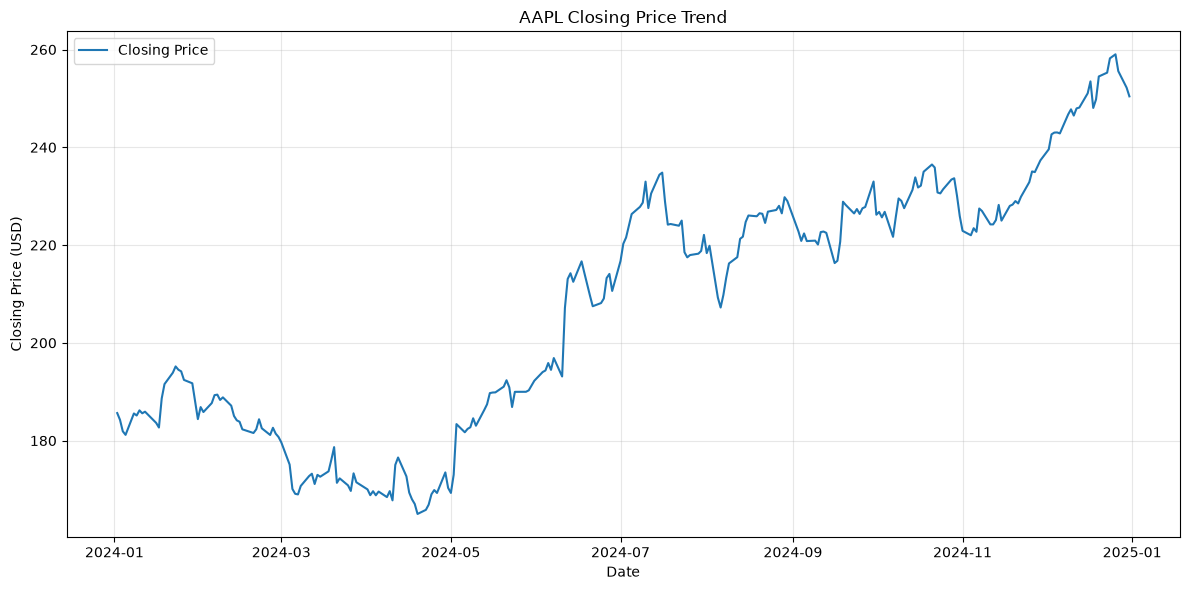

In [8]:
# Create a line chart showing the historical closing price of AAPL
plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Close"], label="Closing Price")

# Add chart title and axis labels
plt.title("AAPL Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

# Display the legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust the layout so labels are not cut off
plt.tight_layout()

# Save the chart as a high-resolution PNG file
plt.savefig("images/closing_price_trend.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

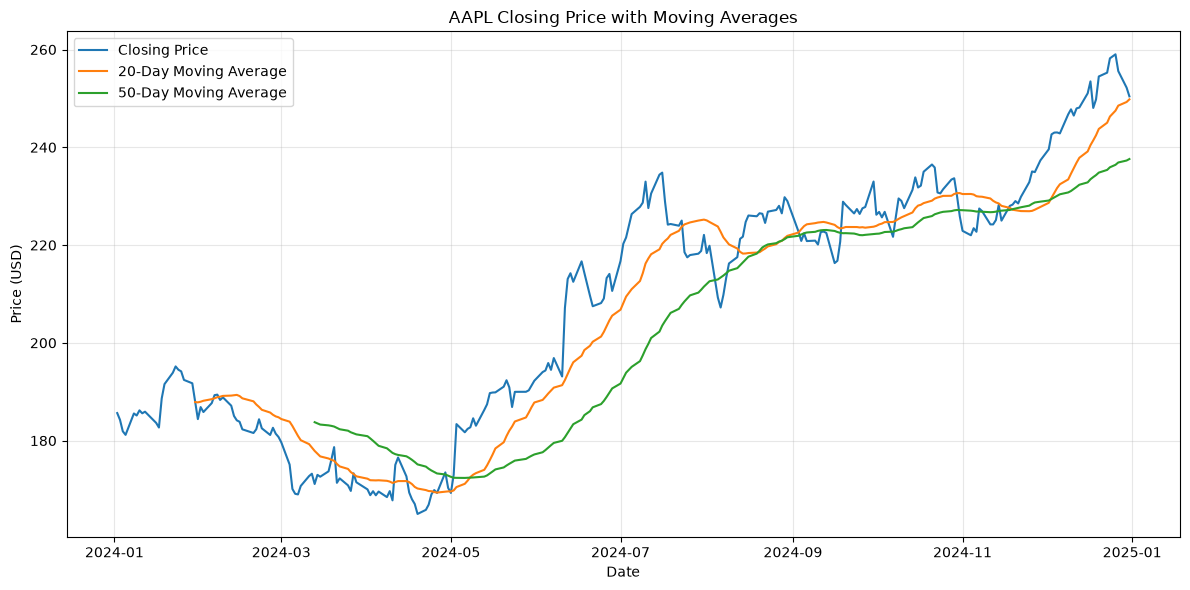

In [9]:
# Create a line chart comparing the closing price with its 20-day and 50-day moving averages
plt.figure(figsize=(12, 6))

# Plot the closing price
plt.plot(df.index, df["Close"], label="Closing Price")

# Plot the 20-day moving average
plt.plot(df.index, df["MA20"], label="20-Day Moving Average")

# Plot the 50-day moving average
plt.plot(df.index, df["MA50"], label="50-Day Moving Average")

# Add chart title and axis labels
plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

# Display the legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Adjust the layout so labels are not cut off
plt.tight_layout()

# Save the chart as a high-resolution PNG file
plt.savefig("images/moving_averages.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

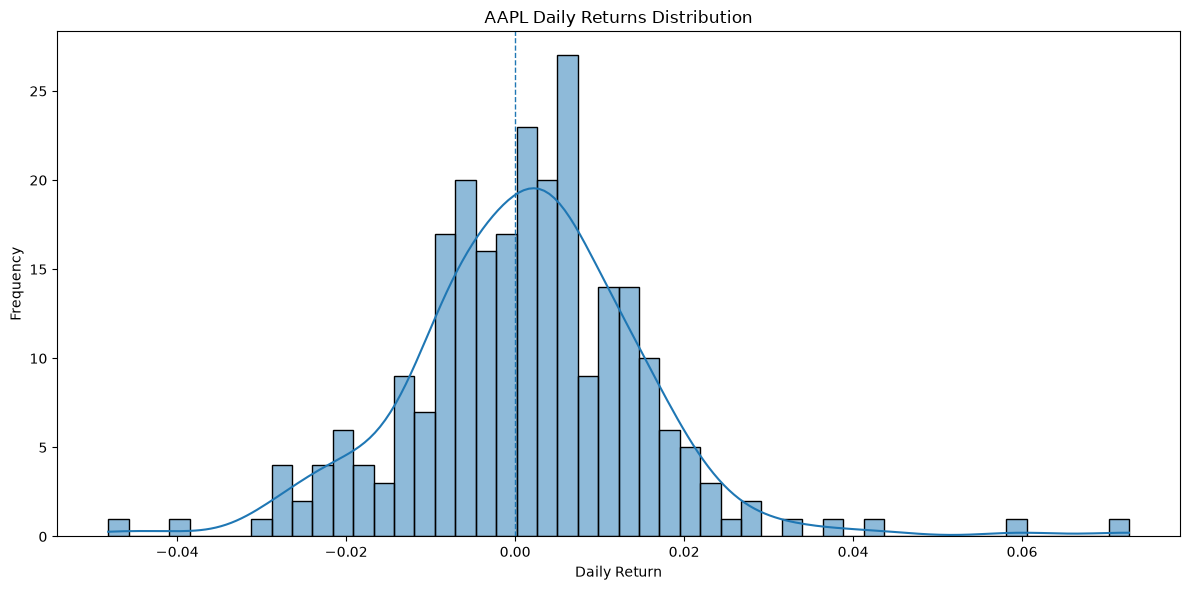

In [10]:
# Create a histogram showing the distribution of AAPL daily returns
plt.figure(figsize=(12, 6))

# Plot the distribution of daily percentage returns
sns.histplot(
    df["Daily_Return"].dropna(),
    bins=50,
    kde=True
)

# Add a vertical line at zero to separate positive and negative returns
plt.axvline(0, linestyle="--", linewidth=1)

# Add chart title and axis labels
plt.title("AAPL Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

# Adjust the layout so labels are not cut off
plt.tight_layout()

# Save the chart as a high-resolution PNG file
plt.savefig("images/daily_returns_distribution.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

In [11]:
# Calculate summary statistics for the stock's return and volatility
total_return = (df["Close"].iloc[-1] / df["Close"].iloc[0]) - 1
mean_daily_return = df["Daily_Return"].mean()
daily_volatility = df["Daily_Return"].std()
annualized_volatility = daily_volatility * np.sqrt(252)
max_daily_gain = df["Daily_Return"].max()
max_daily_loss = df["Daily_Return"].min()
positive_days = (df["Daily_Return"] > 0).sum()
negative_days = (df["Daily_Return"] < 0).sum()

# Display the calculated statistics
print(f"Total Return: {total_return:.2%}")
print(f"Mean Daily Return: {mean_daily_return:.4%}")
print(f"Daily Volatility: {daily_volatility:.4%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"Largest Daily Gain: {max_daily_gain:.2%}")
print(f"Largest Daily Loss: {max_daily_loss:.2%}")
print(f"Positive Trading Days: {positive_days}")
print(f"Negative Trading Days: {negative_days}")

Total Return: 34.90%
Mean Daily Return: 0.1292%
Daily Volatility: 1.4125%
Annualized Volatility: 22.42%
Largest Daily Gain: 7.26%
Largest Daily Loss: -4.82%
Positive Trading Days: 142
Negative Trading Days: 108


## Volatility and Return Interpretation

From January 2024 to January 2025, AAPL recorded a total return of 34.90%, with an average daily return of 0.1292%. The stock had a daily volatility of 1.4125%, equivalent to an annualized volatility of 22.42%, indicating noticeable day-to-day price fluctuations during the period.

AAPL had 142 positive trading days and 108 negative trading days, meaning positive-return days occurred more frequently within the selected period. The largest daily gain was 7.26%, while the largest daily loss was -4.82%. The difference between these daily extremes shows that the stock experienced periods of relatively large short-term price movements.

Overall, the data shows that AAPL generated a positive return during the selected period while also experiencing substantial daily price variation. The moving averages and daily return distribution provide additional context for observing its price trend and short-term volatility.

## Reproducibility and Date-Range Instructions

The analysis can be reproduced for any supported stock ticker and date range by changing the variables in the configuration cell.

```python
TICKER = "AAPL"
START_DATE = "2024-01-01"
END_DATE = "2025-01-01"